In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
data=pd.read_csv('house_price_regression_dataset.csv')
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [9]:
data.shape

(1000, 8)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [11]:
print(data.isnull().sum())

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


In [12]:
print(data.duplicated().sum())

0


In [13]:
X = data[
    [
        "Square_Footage",
        "Num_Bedrooms",
        "Num_Bathrooms",
        "Year_Built",
        "Lot_Size",
        "Garage_Size",
        "Neighborhood_Quality"
    ]
]

y = data["House_Price"]

In [14]:
print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality  
0            0                     5  
1            1                     6  
2            0                     9  
3            1                     8  
4            0                     8  

Target:
0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 7)
Testing data: (200, 7)


In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 868687.10747903  490337.89825447  945667.12422537 1033402.87599247
  776698.77390587  732444.09335308  995051.99156272  885174.76924362
  796730.53817137  931741.09209272]


In [18]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,9.010005e+05,8.686871e+05
1,4.945375e+05,4.903379e+05
2,9.494042e+05,9.456671e+05
3,1.040389e+06,1.033403e+06
4,7.940100e+05,7.766988e+05
5,7.240336e+05,7.324441e+05
6,9.984392e+05,9.950520e+05
7,9.097134e+05,8.851748e+05
8,7.926815e+05,7.967305e+05
9,9.474908e+05,9.317411e+05


In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 8174.5836000087365
MSE : 101434798.50566821
RMSE: 10071.484424138689
R²  : 0.9984263636823408


In [20]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Square_Footage,199.513245
1,Num_Bedrooms,10225.204424
2,Num_Bathrooms,8208.434778
3,Year_Built,993.537171
4,Lot_Size,14885.384415
5,Garage_Size,5146.148383
6,Neighborhood_Quality,115.068595


In [21]:
print("Intercept:", model.intercept_)

Intercept: -2010567.4202702045


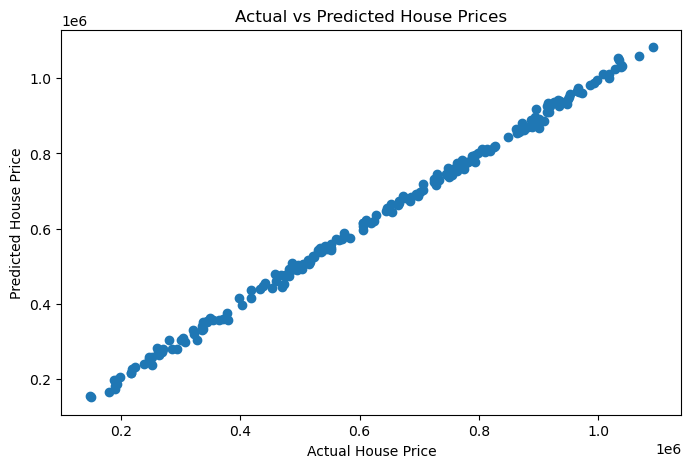

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()